# PA1 ML workflow and decision tree
## Group 38

**Group Members:**
 - Sezin Kokum Mutludogan
 - Priyanka Machchhar 

## Task 0: Making sure that you have the required libraries

We used Anaconda to create a virtual environment. We installed *jupyter notebook*, *scikit-learn* and *pandas*. As seen in the below cell, it doesn't give any error when we import scikit-learn and pandas.

In [1]:
import sklearn
import pandas as pd

## Task 1: A classification example: fetal heart condition diagnosis

#### Step 1. Reading the data

We read the data with the given code snippet and then printed the first 5 rows with head() of pandas library. Everything worked without an error.

In [188]:
from sklearn.model_selection import train_test_split
  
# Read the CSV file.
data = pd.read_csv('CTG.csv', skiprows=1)

# Select the relevant numerical columns.
selected_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
                 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean',
                 'Median', 'Variance', 'Tendency', 'NSP']
data = data[selected_cols].dropna()

# Shuffle the dataset.
data_shuffled = data.sample(frac=1.0, random_state=0)

# Split into input part X and output part Y.
X = data_shuffled.drop('NSP', axis=1)

# Map the diagnosis code to a human-readable label.
def to_label(y):
    return [None, 'normal', 'suspect', 'pathologic'][(int(y))]

Y = data_shuffled['NSP'].apply(to_label)

# Partition the data into training and test sets.
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=0)

In [189]:
X.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency
658,130.0,1.0,0.0,3.0,0.0,0.0,0.0,24.0,1.2,12.0,...,35.0,120.0,155.0,1.0,0.0,134.0,133.0,135.0,1.0,0.0
1734,134.0,9.0,1.0,8.0,5.0,0.0,0.0,59.0,1.2,0.0,...,109.0,80.0,189.0,6.0,0.0,150.0,146.0,150.0,33.0,0.0
1226,125.0,1.0,0.0,4.0,0.0,0.0,0.0,43.0,0.7,31.0,...,21.0,120.0,141.0,0.0,0.0,131.0,130.0,132.0,1.0,0.0
1808,143.0,0.0,0.0,1.0,0.0,0.0,0.0,69.0,0.3,6.0,...,27.0,132.0,159.0,1.0,0.0,145.0,144.0,146.0,1.0,0.0
825,152.0,0.0,0.0,4.0,0.0,0.0,0.0,62.0,0.4,59.0,...,25.0,136.0,161.0,0.0,0.0,159.0,156.0,158.0,1.0,1.0


#### Step 2. Training the baseline classifier

We used dummy classifier with most frequent strategy as given in the assignment description. Then we checked its cross validation score. It gives 78% since the sample numbers of most frequent class is 78% of the all samples.

In [190]:
from sklearn.dummy import DummyClassifier

clf = DummyClassifier(strategy='most_frequent')

In [191]:
from sklearn.model_selection import cross_val_score

print(cross_val_score(clf, Xtrain, Ytrain).mean())

0.7805882352941176


#### Step 3. Trying out some different classifiers

We have used all classifiers that was given in the assignment description below and printed their cross validation accuracies.

In [199]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

print(f"Decision Tree Classifier: {cross_val_score(DecisionTreeClassifier(), Xtrain, Ytrain).mean()}")
print(f"Random Forest Classifier: {cross_val_score(RandomForestClassifier(), Xtrain, Ytrain).mean()}")
print(f"Gradient Boosting Classifier: {cross_val_score(GradientBoostingClassifier(), Xtrain, Ytrain).mean()}")
print(f"Perceptron: {cross_val_score(Perceptron(), Xtrain, Ytrain).mean()}")
print(f"Logistic Regression: {cross_val_score(LogisticRegression(solver='newton-cholesky'), Xtrain, Ytrain).mean()}")
print(f"Linear SVC: {cross_val_score(LinearSVC(), Xtrain, Ytrain).mean()}")
print(f"MLP Classifier: {cross_val_score(MLPClassifier(), Xtrain, Ytrain).mean()}")

Decision Tree Classifier: 0.9229411764705882
Random Forest Classifier: 0.9394117647058824
Gradient Boosting Classifier: 0.9494117647058824
Perceptron: 0.825294117647059
Logistic Regression: 0.8905882352941177
Linear SVC: 0.8952941176470588
MLP Classifier: 0.881764705882353


#### Step 4. Final evaluation

The best three classifiers among others according to their cross validation accuracies:
 - Gradient Boosting Classifier: 94.94%
 - Random Forest Classifier: 93.94%
 - Decision Tree Classifier: 92.29%

Since **Gradient Boosting Classifier** has the highest cross validation accuracy, we tested it against the test set below. We used accuracy score as metric and we got 92.96% accuracy.

According to the sklearn documentation, Gradient Boosting Classifier is an ensemble method. To increase generalizability and robustness over a single estimator, ensemble approaches integrate the predictions of many base estimators constructed with a particular learning methodology. The Gradient Boosting Classifier algorithm optimizes arbitrary differentiable loss functions by building an additive model in a forward, stage-wise manner.

In [201]:
from sklearn.metrics import accuracy_score

clf = GradientBoostingClassifier()
clf.fit(Xtrain, Ytrain)
Yguess = clf.predict(Xtest)
print(accuracy_score(Ytest, Yguess))

0.9295774647887324


## Task 2: Decision trees for classification

In the following 5 cells, we used the implementation of TreeClassifier from the Lecture 1 notebook.

In [202]:
import numpy as np

def majority_sum_scorer(n_low, low_distr, n_high, high_distr):
    maj_sum_low = low_distr.most_common(1)[0][1]
    maj_sum_high = high_distr.most_common(1)[0][1]
    return maj_sum_low + maj_sum_high

In [203]:
class DecisionTreeLeaf:

    def __init__(self, value):
        self.value = value

    # This method computes the prediction for this leaf node. This will just return a constant value.
    def predict(self, x):
        return self.value

    # Utility function to draw a tree visually using graphviz.
    def draw_tree(self, graph, node_counter, names):
        node_id = str(node_counter)
        val_str = f'{self.value:.4g}' if isinstance(self.value, float) else str(self.value)
        graph.node(node_id, val_str, style='filled')
        return node_counter+1, node_id
        
    def __eq__(self, other):
        if isinstance(other, DecisionTreeLeaf):
            return self.value == other.value
        else:
            return False

In [204]:
class DecisionTreeBranch:

    def __init__(self, feature, threshold, low_subtree, high_subtree):
        self.feature = feature
        self.threshold = threshold
        self.low_subtree = low_subtree
        self.high_subtree = high_subtree

    # For a branch node, we compute the prediction by first considering the feature, and then 
    # calling the upper or lower subtree, depending on whether the feature is or isn't greater
    # than the threshold.
    def predict(self, x):
        if x[self.feature] <= self.threshold:
            return self.low_subtree.predict(x)
        else:
            return self.high_subtree.predict(x)

    # Utility function to draw a tree visually using graphviz.
    def draw_tree(self, graph, node_counter, names):
        node_counter, low_id = self.low_subtree.draw_tree(graph, node_counter, names)
        node_counter, high_id = self.high_subtree.draw_tree(graph, node_counter, names)
        node_id = str(node_counter)
        fname = f'F{self.feature}' if names is None else names[self.feature]
        lbl = f'{fname} > {self.threshold:.4g}?'
        graph.node(node_id, lbl, shape='box', fillcolor='yellow', style='filled, rounded')
        graph.edge(node_id, low_id, 'False')
        graph.edge(node_id, high_id, 'True')
        return node_counter+1, node_id
        

In [205]:
from graphviz import Digraph
from sklearn.base import BaseEstimator, ClassifierMixin
from abc import ABC, abstractmethod

class DecisionTree(ABC, BaseEstimator):

    def __init__(self, max_depth):
        super().__init__()
        self.max_depth = max_depth

    # As usual in scikit-learn, the training method is called *fit*. We first process the dataset so that
    # we're sure that it's represented as a NumPy matrix. Then we call the recursive tree-building method
    # called make_tree (see below).
    def fit(self, X, Y):
        if isinstance(X, pd.DataFrame):
            self.names = X.columns
            X = X.to_numpy()
        elif isinstance(X, list):
            self.names = None
            X = np.array(X)
        else:
            self.names = None
        Y = np.array(Y)        
        self.root = self.make_tree(X, Y, self.max_depth)

    def draw_tree(self):
        graph = Digraph()
        self.root.draw_tree(graph, 0, self.names)
        return graph

    # By scikit-learn convention, the method *predict* computes the classification or regression output
    # for a set of instances.
    # To implement it, we call a separate method that carries out the prediction for one instance.
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()
        return [self.predict_one(x) for x in X]

    # Predicting the output for one instance.
    def predict_one(self, x):
        return self.root.predict(x)        

    # This is the recursive training 
    def make_tree(self, X, Y, max_depth):

        # We start by computing the default value that will be used if we'll return a leaf node.
        # For classifiers, this will be the most common value in Y.
        default_value = self.get_default_value(Y)

        # First the two base cases in the recursion: is the training set completely
        # homogeneous, or have we reached the maximum depth? Then we need to return a leaf.

        # If we have reached the maximum depth, return a leaf with the majority value.
        if max_depth == 0:
            return DecisionTreeLeaf(default_value)

        # If all the instances in the remaining training set have the same output value,
        # return a leaf with this value.
        if self.is_homogeneous(Y):
            return DecisionTreeLeaf(default_value)

        # Select the "most useful" feature and split threshold. To rank the "usefulness" of features,
        # we use one of the classification or regression criteria.
        # For each feature, we call best_split (defined in a subclass). We then maximize over the features.
        n_features = X.shape[1]
        _, best_feature, best_threshold = max(self.best_split(X, Y, feature) for feature in range(n_features))

        if best_feature is None:
            return DecisionTreeLeaf(default_value)

        # Split the training set into subgroups, based on whether the selected feature is greater than
        # the threshold or not
        X_low, X_high, Y_low, Y_high = self.split_by_feature(X, Y, best_feature, best_threshold)

        # Build the subtrees using a recursive call. Each subtree is associated
        # with a value of the feature.
        low_subtree = self.make_tree(X_low, Y_low, max_depth-1)
        high_subtree = self.make_tree(X_high, Y_high, max_depth-1)

        if low_subtree == high_subtree:
            return low_subtree

        # Return a decision tree branch containing the result.
        return DecisionTreeBranch(best_feature, best_threshold, low_subtree, high_subtree)

    # Utility method that splits the data into the "upper" and "lower" part, based on a feature
    # and a threshold.
    def split_by_feature(self, X, Y, feature, threshold):
        low = X[:,feature] <= threshold
        high = ~low
        return X[low], X[high], Y[low], Y[high]

    # The following three methods need to be implemented by the classification and regression subclasses.

    @abstractmethod
    def get_default_value(self, Y):
        pass

    @abstractmethod
    def is_homogeneous(self, Y):
        pass

    @abstractmethod
    def best_split(self, X, Y, feature):
        pass

In [206]:
from collections import Counter

class TreeClassifier(DecisionTree, ClassifierMixin):

    def __init__(self, max_depth=10, criterion='maj_sum'):
        super().__init__(max_depth)
        self.criterion = criterion

    def fit(self, X, Y):
        # For decision tree classifiers, there are some different ways to measure
        # the homogeneity of subsets.
        if self.criterion == 'maj_sum':
            self.criterion_function = majority_sum_scorer
        elif self.criterion == 'info_gain':
            self.criterion_function = info_gain_scorer
        elif self.criterion == 'gini':
            self.criterion_function = gini_scorer
        else:
            raise Exception(f'Unknown criterion: {self.criterion}')
        super().fit(X, Y)
        self.classes_ = sorted(set(Y))

    # Select a default value that is going to be used if we decide to make a leaf.
    # We will select the most common value.
    def get_default_value(self, Y):
        self.class_distribution = Counter(Y)
        return self.class_distribution.most_common(1)[0][0]

    # Checks whether a set of output values is homogeneous. In the classification case, 
    # this means that all output values are identical.
    # We assume that we called get_default_value just before, so that we can access
    # the class_distribution attribute. If the class distribution contains just one item,
    # this means that the set is homogeneous.
    def is_homogeneous(self, Y):
        return len(self.class_distribution) == 1

    # Finds the best splitting point for a given feature. We'll keep frequency tables (Counters)
    # for the upper and lower parts, and then compute the impurity criterion using these tables.
    # In the end, we return a triple consisting of
    # - the best score we found, according to the criterion we're using
    # - the id of the feature
    # - the threshold for the best split
    def best_split(self, X, Y, feature):

        # Create a list of input-output pairs, where we have sorted
        # in ascending order by the input feature we're considering.
        sorted_indices = np.argsort(X[:, feature])        
        X_sorted = list(X[sorted_indices, feature])
        Y_sorted = list(Y[sorted_indices])

        n = len(Y)

        # The frequency tables corresponding to the parts *before and including*
        # and *after* the current element.
        low_distr = Counter()
        high_distr = Counter(Y)

        # Keep track of the best result we've seen so far.
        max_score = -np.inf
        max_i = None

        # Go through all the positions (excluding the last position).
        for i in range(0, n-1):

            # Input and output at the current position.
            x_i = X_sorted[i]
            y_i = Y_sorted[i]

            # Update the frequency tables.
            low_distr[y_i] += 1
            high_distr[y_i] -= 1

            # If the input is equal to the input at the next position, we will
            # not consider a split here.
            #x_next = XY[i+1][0]
            x_next = X_sorted[i+1]
            if x_i == x_next:
                continue

            # Compute the homogeneity criterion for a split at this position.
            score = self.criterion_function(i+1, low_distr, n-i-1, high_distr)

            # If this is the best split, remember it.
            if score > max_score:
                max_score = score
                max_i = i

        # If we didn't find any split (meaning that all inputs are identical), return
        # a dummy value.
        if max_i is None:
            return -np.inf, None, None

        # Otherwise, return the best split we found and its score.
        split_point = 0.5*(X_sorted[max_i] + X_sorted[max_i+1])
        return max_score, feature, split_point


#### max_depth selection:

Below we tried different max_depth parameters to find the best cross validation score. We iterated from 0 to 20 and checked their cross validation scores. max_depth=13 was the parameter which gave the best score with 91.71%. We also plotted cross validation accuracies for each max_depth parameters we tried.

Highest cross validation score is 0.9170588235294117 with max_depth 13


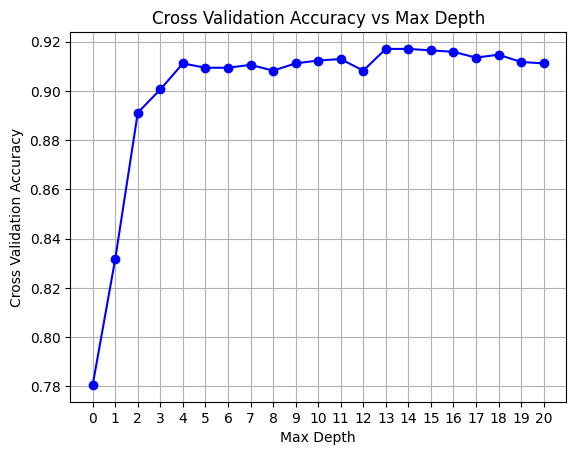

In [214]:
import matplotlib.pyplot as plt

scores = []

for i in range(21):
    clf = TreeClassifier(max_depth=i)
    score = cross_val_score(clf, Xtrain, Ytrain)

    scores.append(score.mean())

print(f"Highest cross validation score is {max(scores)} with max_depth {scores.index(max(scores))}")

plt.plot(list(range(21)), scores, marker='o', linestyle='-', color='b')

plt.xlabel('Max Depth')
plt.ylabel('Cross Validation Accuracy')
plt.title('Cross Validation Accuracy vs Max Depth')
plt.xticks(list(range(21)))
plt.grid(True)
plt.show()

#### Accuracy on the test set:

We trained the classifier with max_depth=13 and checked its accuracy score on the test set. We got 87.32%.



In [215]:
clf = TreeClassifier(max_depth=13)

clf.fit(Xtrain, Ytrain)
Yguess = clf.predict(Xtest)
print(accuracy_score(Ytest, Yguess))

0.8732394366197183


#### Visualization:

For visualization, we draw a tree with max_depth=3

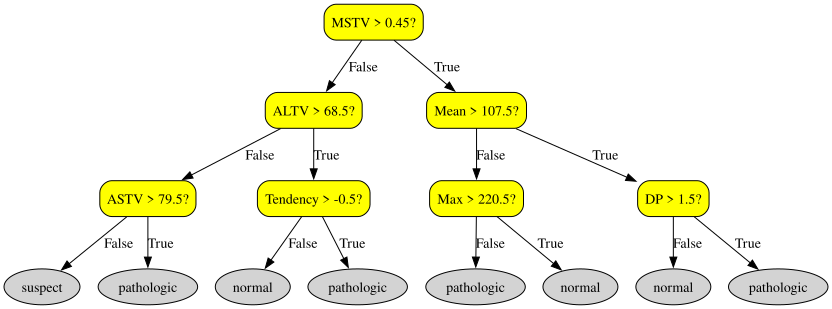

In [216]:
cls_tc_draw = TreeClassifier(max_depth=3)

cls_tc_draw.fit(Xtrain, Ytrain)
cls_tc_draw.draw_tree()

## Task 3: A regression example: predicting property prices

For this task, we used the property prices dataset from Hemnet. We did the same approach what we did in the classifier example. We have used all regression models that was given in the assignment description below. We used negative mean squared error metric to evaluate the models. Random Forest Regression has the highest negative error so we chose this model for evaluation on the test set.

Finally we trained on the full training set with Random Forest Regression model and evaluated on the held-out test set. We used mean squared error as the metric and we got 0.1344.

In [218]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Read the Excel file using Pandas.
alldata = pd.read_excel('Hemnet_data.xlsx')

# # Convert the timestamp string to an integer representing the year.
alldata['year'] = pd.DatetimeIndex(alldata['Sold Date']).year

# Convert 'yes' to 1 and 'no' to 0
alldata['Balcony'] = alldata['Balcony'].map({'Yes': 1, 'No': 0})
alldata['Patio'] = alldata['Patio'].map({'Yes': 1, 'No': 0})
alldata['Lift'] = alldata['Lift'].map({'Yes': 1, 'No': 0})

# Convert string prices to float
alldata['Final Price (kr)'] = alldata['Final Price (kr)'].astype(str).str.replace('kr', '', regex=True).astype(float)
alldata['Fee (kr/month)'] = alldata['Fee (kr/month)'].astype(str).str.replace('kr', '', regex=True).astype(float)
alldata['Operating Fee (kr/year)'] = alldata['Operating Fee (kr/year)'].astype(str).str.replace('kr', '', regex=True).astype(float)

# Select the 12 input columns and the output column.
selected_columns = ['Final Price (kr)', 'year',  'Num of Room', 'Living Area (m²)', 'Balcony', 'Patio','Current Floor', 'Total Floor', 'Lift', 'Built Year', 'Fee (kr/month)', 'Operating Fee (kr/year)']
alldata = alldata[selected_columns]
alldata = alldata.dropna()

# Shuffle.
alldata_shuffled = alldata.sample(frac=1.0, random_state=0)

# Separate the input and output columns.
X = alldata_shuffled.drop('Final Price (kr)', axis=1)
# For the output, we'll use the log of the sales price.
Y = alldata_shuffled['Final Price (kr)'].apply(np.log)

# Split into training and test sets.
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=0)

In [221]:
from sklearn.model_selection import cross_validate
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

print(f"Dummy Regressor: \
{cross_validate(DummyRegressor(), Xtrain, Ytrain, scoring='neg_mean_squared_error')['test_score'].mean()}")

print(f"Linear Regression: \
{cross_validate(LinearRegression(), Xtrain, Ytrain, scoring='neg_mean_squared_error')['test_score'].mean()}")

print(f"Ridge: \
{cross_validate(Ridge(), Xtrain, Ytrain, scoring='neg_mean_squared_error')['test_score'].mean()}")

print(f"Lasso: \
{cross_validate(Lasso(), Xtrain, Ytrain, scoring='neg_mean_squared_error')['test_score'].mean()}")

print(f"Decision Tree Regressor: \
{cross_validate(DecisionTreeRegressor(), Xtrain, Ytrain, scoring='neg_mean_squared_error')['test_score'].mean()}")

print(f"Random Forest Regressor: \
{cross_validate(RandomForestRegressor(), Xtrain, Ytrain, scoring='neg_mean_squared_error')['test_score'].mean()}")

print(f"Gradient Boosting Regressor: \
{cross_validate(GradientBoostingRegressor(), Xtrain, Ytrain, scoring='neg_mean_squared_error')['test_score'].mean()}")

print(f"MLP Regressor: \
{cross_validate(MLPRegressor(), Xtrain, Ytrain, scoring='neg_mean_squared_error')['test_score'].mean()}")

Dummy Regressor: -0.34593721954567236
Linear Regression: -0.2204405551756087
Ridge: -0.2204396799216287
Lasso: -0.27918803963207817
Decision Tree Regressor: -0.2790829414815591
Random Forest Regressor: -0.14896401589240665
Gradient Boosting Regressor: -0.15790562078876016
MLP Regressor: -9.643302362399428


In [223]:
from sklearn.metrics import mean_squared_error

regr = RandomForestRegressor()
regr.fit(Xtrain, Ytrain)
mean_squared_error(Ytest, regr.predict(Xtest))

0.134427011465942

## Task 4: Decision trees for regression

#### Step 1. Implementing the regression model

We adapted TreeClassifier for regression. In the constructor, we added homogeneity_threshold parameter with the default value of 0.01 to be used in is_homogeneous function. We used mean in get_default_value and variance in is_homogeneous. As a homogeneity criterion, we used variance reduction. We have updated the best_split function to calculate variance for sub trees of the selected threshold and use the criterion function to calculate homogeneity with these variances.

In [227]:
from sklearn.base import RegressorMixin

def variance_reduction_scorer(total_var, total_n, low_var, low_n, high_var, high_n):
    return total_var - (high_n/total_n*high_var) - (low_n/total_n*low_var)

class TreeRegressor(DecisionTree, RegressorMixin):

    def __init__(self, max_depth=10, criterion='variance_reduction', homogeneity_threshold=0.01):
        super().__init__(max_depth)
        self.criterion = criterion
        self.homogeneity_threshold = homogeneity_threshold

    def fit(self, X, Y):
        # For decision tree classifiers, there are some different ways to measure
        # the homogeneity of subsets.
        if self.criterion == 'variance_reduction':
            self.criterion_function = variance_reduction_scorer
        else:
            raise Exception(f'Unknown criterion: {self.criterion}')
        super().fit(X, Y)
        self.classes_ = sorted(set(Y))

    # Default value is the mean
    def get_default_value(self, Y):
        return np.mean(Y)

    # Checks whether a set of output values is homogeneous.
    def is_homogeneous(self, Y):
        return np.var(Y) < self.homogeneity_threshold

    # Finds the best splitting point for a given feature.
    # In the end, we return a triple consisting of
    # - the best score we found, according to the criterion we're using
    # - the id of the feature
    # - the threshold for the best split
    def best_split(self, X, Y, feature):

        # Create a list of input-output pairs, where we have sorted
        # in ascending order by the input feature we're considering.
        sorted_indices = np.argsort(X[:, feature])        
        X_sorted = list(X[sorted_indices, feature])
        Y_sorted = list(Y[sorted_indices])

        n = len(Y)
        total_var = np.var(Y)

        # Initialize sum, sum of squares and count for lower and higher sub trees.
        low_sum = 0
        low_sum_sq = 0
        low_n = 0

        high_sum = np.sum(Y)
        high_sum_sq = np.sum(Y**2)
        high_n = n
        
        # Keep track of the best result we've seen so far.
        max_score = -np.inf
        max_i = None

        # Go through all the positions (excluding the last position).
        for i in range(0, n-1):

            # Input and output at the current position.
            x_i = X_sorted[i]
            y_i = Y_sorted[i]

            # Update sums, sum of squares and counts of sub trees.
            low_sum += y_i
            low_sum_sq += y_i**2
            low_n += 1

            high_sum -= y_i
            high_sum_sq -= y_i**2
            high_n -= 1

            # If the input is equal to the input at the next position, we will
            # not consider a split here.
            #x_next = XY[i+1][0]
            x_next = X_sorted[i+1]
            if x_i == x_next:
                continue

            # Compute the homogeneity criterion for a split at this position.
            low_var = low_sum_sq/low_n - (low_sum/low_n)**2
            high_var = high_sum_sq/high_n - (high_sum/high_n)**2
            score = self.criterion_function(total_var, n, low_var, low_n, high_var, high_n)

            # If this is the best split, remember it.
            if score > max_score:
                max_score = score
                max_i = i

        # If we didn't find any split (meaning that all inputs are identical), return
        # a dummy value.
        if max_i is None:
            return -np.inf, None, None

        # Otherwise, return the best split we found and its score.
        split_point = 0.5*(X_sorted[max_i] + X_sorted[max_i+1])
        return max_score, feature, split_point


#### Step 2. Sanity check

For this step, we created a small dataset with the function given in the assignment description. When we look at the data, we see that samples are distributed around 0 if `x <= 1` and they are distributed around 1 if `x > 1`. A tree with depth = 1 can describe this data by splitting around `x = 1`. The drawing of the two trees trained on the same data with `max_depth=1` and `max_depth=10` are the same and using maximum 1 depth. This also supports our initial idea about the dataset.

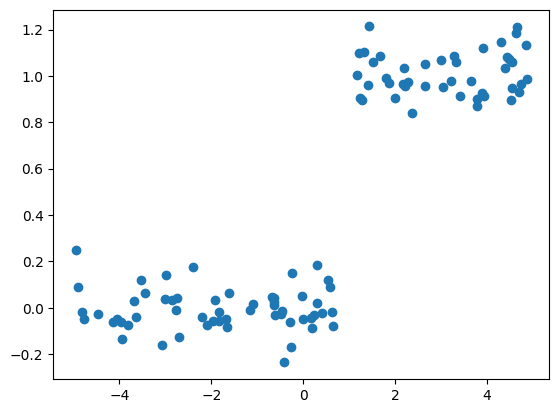

In [241]:
def make_some_data(n):
    x = np.random.uniform(-5, 5, size=n)
    Y = (x > 1) + 0.1*np.random.normal(size=n)
    X = x.reshape(n, 1) # X needs to be a 2-dimensional matrix
    return X, Y

Xsanity, Ysanity = make_some_data(100)

plt.scatter(Xsanity, Ysanity)
plt.show()

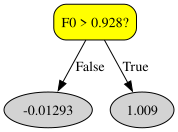

In [242]:
Xtrain_sanity, Xtest_sanity, Ytrain_sanity, Ytest_sanity = train_test_split(Xsanity, Ysanity, test_size=0.2, random_state=0)

regr = TreeRegressor(max_depth=1)
regr.fit(Xtrain_sanity, Ytrain_sanity)
regr.draw_tree()

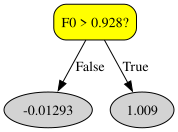

In [243]:
regr = TreeRegressor(max_depth=10)
regr.fit(Xtrain_sanity, Ytrain_sanity)
regr.draw_tree()

#### Step 3. Predicting apartment prices using decision tree regression

We checked different max_depth values from 0 to 12 against cross validation score as we did before. According to these results, the best value for max_depth was 7. So, we trained the tree with max_depth=7 and tested it against the test set by using mean squared error as the evaluation metric. We got 0.1728.

In [244]:
scores = []

for i in range(13):
    clf = TreeRegressor(max_depth=i)
    score = cross_val_score(clf, Xtrain, Ytrain)

    scores.append(score.mean())

depth = scores.index(max(scores))
print(f"Max depth: {depth}")

regr = TreeRegressor(max_depth=depth)
regr.fit(Xtrain, Ytrain)
print(f"Mean squared error: {mean_squared_error(Ytest, regr.predict(Xtest))}")

Max depth: 7
Mean squared error: 0.17278197326065306


#### Step 4. Underfitting and overfitting

When we compare the train and test error for different max_depth values, we see that train error always decreases when the max_depth increases. But for the test error, it decreases until some point (7 for this case) then it starts to increase. The gap between train and test error curves widens after that point. Getting higher test errors while train error decreasing shows that model starts to overfit after some point.

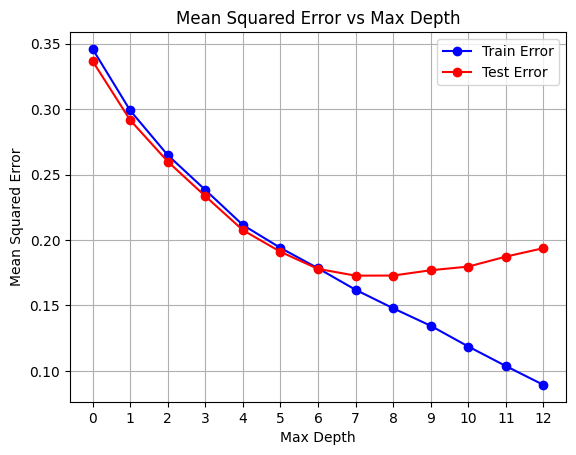

In [245]:
train_errors = []
test_errors = []

for i in range(13):
    regr = TreeRegressor(max_depth=i)
    regr.fit(Xtrain, Ytrain)
    train_error = mean_squared_error(Ytrain, regr.predict(Xtrain))
    test_error = mean_squared_error(Ytest, regr.predict(Xtest))

    train_errors.append(train_error)
    test_errors.append(test_error)

plt.plot(list(range(13)), train_errors, marker='o', linestyle='-', color='b', label='Train Error')
plt.plot(list(range(13)), test_errors, marker='o', linestyle='-', color='r', label='Test Error')

plt.xlabel('Max Depth')
plt.ylabel('Mean Squared Error')
plt.title('Mean Squared Error vs Max Depth')
plt.xticks(list(range(13)))
plt.grid(True)
plt.legend()
plt.show()